In [8]:
# Load libraries
library(dplyr)
library(ggplot2)
library(tidyverse)
library(ggpubr)
library(Hmisc)


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
✔ readr     2.1.5     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘Hmisc’




The following objects are masked from ‘package:dplyr’:

    src, summarize




The following objects are masked from ‘package:base’:

    format.pval, units




In [9]:
# Set working dir to processed data folder
setwd("../data/processed_data")
fish_cost <- read.csv("portugal_fishery_stats.csv")
atlantic_climate <- read.csv("atlantic_ocean_temp.csv")

ERROR: Error in setwd("../data/processed_data"): cannot change working directory


In [10]:
list.files()

[1] "README.md"          "top_5_landings.csv"

In [6]:
# Load datasets
top_5_landings <- read.csv("top_5_landings.csv")

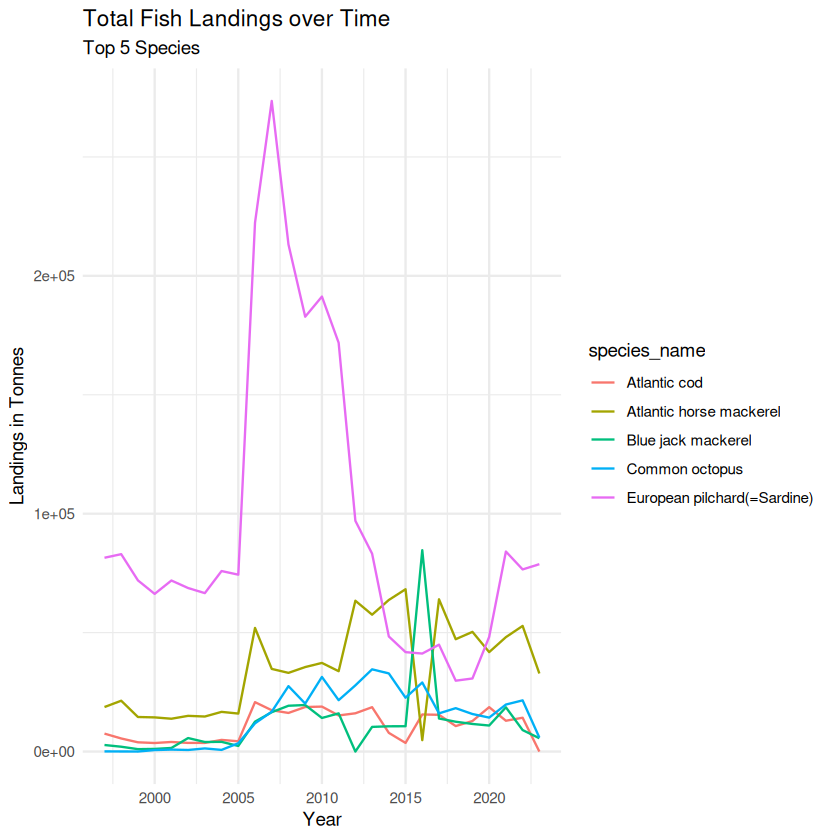

In [11]:
viz4 <- ggplot(top_5_landings, aes(x = year, y = total_landings, color = species_name, group = species_name)) +
  geom_line() +
  labs(
    title = "Total Fish Landings over Time",
    subtitle = "Top 5 Species",
    x = "Year",
    y = "Landings in Tonnes"
  ) +
  theme_minimal()

viz4

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


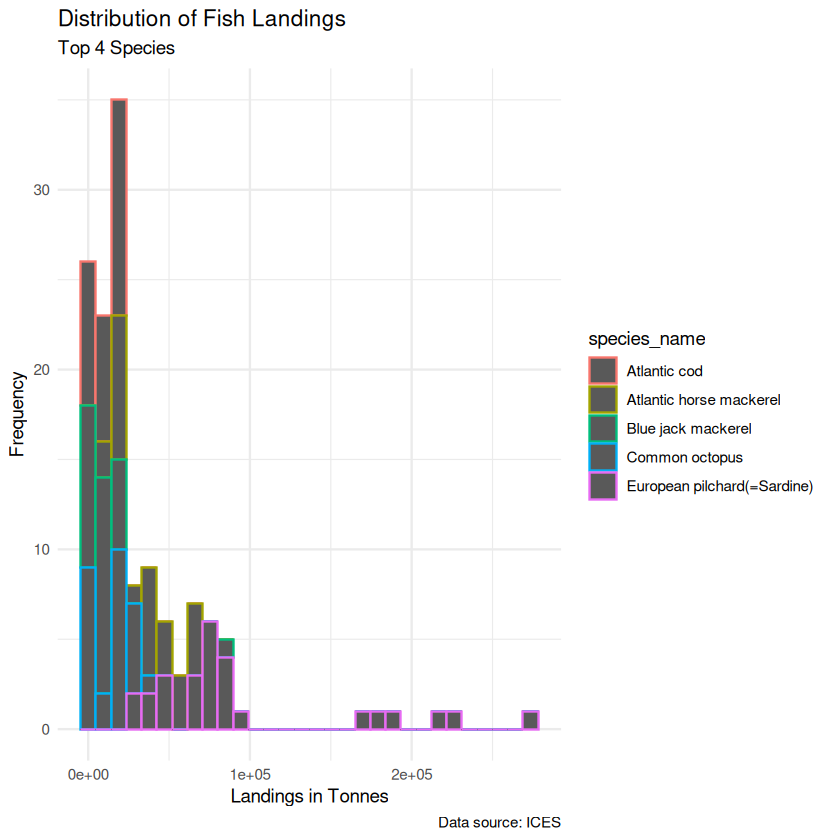

In [13]:
viz1 <- ggplot(top_5_landings, aes(x = total_landings, color = species_name, group = species_name)) +
  geom_histogram() +
  labs(
    title = "Distribution of Fish Landings",
    subtitle = "Top 4 Species",  # Optional
    x = "Landings in Tonnes",
    y = "Frequency",
    caption = "Data source: ICES"  # Optional
  ) +
  theme_minimal()

viz1

In [0]:
final_df <- pt_sum_landings %>%
  left_join(atlantic_climate, by = "year")

head(final_df)


head(atlantic_climate)

viz5 <- ggplot(atlantic_climate, aes(x = year, y = max)) +
  geom_line() +
  labs(
    title = "Atlantic Ocean Climate Over Time",
    x = "Year",
    y = "Max Temperature in C"
  ) +
  theme_minimal()

viz5

In [0]:
# VISUALIZATION 2: Relationship or Comparison

pil <- final_df %>%
  filter(species_code == "PIL")

hom <- final_df %>%
  filter(species_code == "HOM")

hke <- final_df %>%
  filter(species_code == "HKE")

fin <- final_df %>%
  filter(species_code == "FIN")

viz2 <- ggplot(pil, aes(x = max, y = total_landings)) +
  geom_point() +
  labs(
    title = "Max Annual Temperature vs Fish Landings",
    subtitle = "For Sardines",
    x = "Max Annual Temp (in C)",
    y = "Fish Landings in Tonnes"
  ) +
  theme_minimal()

viz2

In [0]:
ggscatter(pil, x = "max", y = "total_landings", 
          add = "reg.line", conf.int = TRUE, 
          cor.coef = TRUE, cor.method = "pearson",
          xlab = "Temperature (C)", ylab = "Landings(tonnes)")

In [0]:
ress3 <- cor.test(final_df$max, final_df$total_landings, method='spearman', exact = FALSE)
ress3

#this means climate does not have a big impact on fish catches currently
#

In [0]:
ress4 <- cor.test(fin$max, fin$total_landings, method='spearman', exact = FALSE)
ress4
